# 03 Model Experiments

Compare a seasonal-naive baseline, ANN, and DNN using chronological splits. Model performance will be measured with MAE, RMSE, and WAPE.

### Imports and configuration

In [28]:
from pathlib import Path
import random
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DATA_DIR, MODEL_DIR, REPORT_DIR

In [29]:
RANDOM_SEED = 42
EXPECTED_STORE_COUNT = 10

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

FEATURE_PATHS = sorted(
    FEATURES_DATA_DIR.glob("store_id=*/features.parquet")
)

if len(FEATURE_PATHS) != EXPECTED_STORE_COUNT:
    raise FileNotFoundError(
        f"Expected {EXPECTED_STORE_COUNT} feature partitions in "
        f"{FEATURES_DATA_DIR}, but found {len(FEATURE_PATHS)}. "
        "Run: python -m src.data.pipeline --overwrite"
    )

STORE_IDS = tuple(
    path.parent.name.removeprefix("store_id=")
    for path in FEATURE_PATHS
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Feature partitions: {len(FEATURE_PATHS)}")
print(f"Stores: {', '.join(STORE_IDS)}")

Project root: D:\Repos\ML-StockPredict
Feature partitions: 10
Stores: CA_1, CA_2, CA_3, CA_4, TX_1, TX_2, TX_3, WI_1, WI_2, WI_3


### Define chronological split dates

The validation and test sets each cover 28 forecast-origin dates. A seven-day purge gap is placed before each set because `target_7d` contains demand from the following seven days. This prevents a training label from overlapping demand used in a later evaluation period.

In [30]:

TRAIN_END = pd.Timestamp("2016-03-06")

VAL_START = pd.Timestamp("2016-03-14")
VAL_END = pd.Timestamp("2016-04-10")

TEST_START = pd.Timestamp("2016-04-18")
TEST_END = pd.Timestamp("2016-05-15")

STORE_IDS = [
    "CA_1",
    "CA_2",
    "CA_3",
    "CA_4",
    "TX_1",
    "TX_2",
    "TX_3",
    "WI_1",
    "WI_2",
    "WI_3",
]

In [31]:
def get_split(df, split):
    dates = pd.to_datetime(df["date"])

    if split == "train":
        mask = dates <= TRAIN_END

    elif split == "val":
        mask = (
            (dates >= VAL_START)
            & (dates <= VAL_END)
        )

    elif split == "test":
        mask = (
            (dates >= TEST_START)
            & (dates <= TEST_END)
        )

    else:
        raise ValueError(
            "split must be train, val or test"
        )

    return df.loc[mask].copy()

In [32]:
df = pd.read_parquet(
    next(
        path
        for path in FEATURE_PATHS
        if path.parent.name == "store_id=CA_1"
    )
)

df["date"] = pd.to_datetime(df["date"])

train_df = get_split(df, "train")
val_df = get_split(df, "val")
test_df = get_split(df, "test")

print("Train:", train_df["date"].min(), train_df["date"].max())
print("Validation:", val_df["date"].min(), val_df["date"].max())
print("Test:", test_df["date"].min(), test_df["date"].max())

print("Train rows:", f"{len(train_df):,}")
print("Validation rows:", f"{len(val_df):,}")
print("Test rows:", f"{len(test_df):,}")

Train: 2011-02-26 00:00:00 2016-03-06 00:00:00
Validation: 2016-03-14 00:00:00 2016-04-10 00:00:00
Test: 2016-04-18 00:00:00 2016-05-15 00:00:00
Train rows: 4,468,127
Validation rows: 85,372
Test rows: 85,372


###  Establish the baseline

Predicted next 7-day sales=actual previous 7-day sales

In [33]:
y_true = val_df["target_7d"].to_numpy()
y_pred = val_df["sales_sum_7"].to_numpy()

In [34]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    error = y_true - y_pred

    mae = np.mean(
        np.abs(error)
    )

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    denominator = np.sum(
        np.abs(y_true)
    )

    wape = (
        np.sum(np.abs(error))
        / denominator
        * 100
        if denominator != 0
        else np.nan
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
    }

In [35]:
baseline_metrics = regression_metrics(
    y_true,
    y_pred
)

print(baseline_metrics)

{'MAE': np.float64(4.175971044370519), 'RMSE': np.float64(8.63621626430888), 'WAPE': np.float64(39.72687916826851)}


### baseline per store

In [36]:
FEATURE_DIR = PROJECT_ROOT / "data" / "processed" / "features"

def store_file(store_id: str) -> Path:
    return (
        FEATURE_DIR
        / f"store_id={store_id}"
        / "features.parquet"
    )

In [37]:
baseline_results = []

overall_abs_error = 0.0
overall_squared_error = 0.0
overall_actual = 0.0
overall_n = 0

for store_id in STORE_IDS:

    print("Processing:", store_id)

    df = pd.read_parquet(
    FEATURE_DIR / f"store_id={store_id}" / "features.parquet",
    columns=[
        "date",
        "sales_sum_7",
        "target_7d",
    ],
    engine="pyarrow",
)

    df["date"] = pd.to_datetime(
        df["date"]
    )

    val = get_split(
        df,
        "val"
    )

    y_true = val[
        "target_7d"
    ].to_numpy()

    y_pred = val[
        "sales_sum_7"
    ].to_numpy()

    metrics = regression_metrics(
        y_true,
        y_pred
    )

    metrics["store_id"] = store_id

    baseline_results.append(
        metrics
    )

    errors = (
        y_true - y_pred
    )

    overall_abs_error += (
        np.abs(errors).sum()
    )

    overall_squared_error += (
        (errors ** 2).sum()
    )

    overall_actual += (
        np.abs(y_true).sum()
    )

    overall_n += len(y_true)

Processing: CA_1
Processing: CA_2
Processing: CA_3
Processing: CA_4
Processing: TX_1
Processing: TX_2
Processing: TX_3
Processing: WI_1
Processing: WI_2
Processing: WI_3


In [38]:
baseline_results_df = pd.DataFrame(
    baseline_results
)

display(
    baseline_results_df[
        [
            "store_id",
            "MAE",
            "RMSE",
            "WAPE",
        ]
    ]
)

,store_id,MAE,RMSE,WAPE
0,CA_1,4.1760,8.6362,39.7269
1,CA_2,4.3578,8.7133,44.1426
2,CA_3,5.1084,11.1648,34.7444
3,CA_4,2.9134,5.3885,48.3119
4,TX_1,3.3105,7.2608,43.4741
5,TX_2,3.6550,7.1739,39.5129
6,TX_3,3.6448,7.7077,41.5522
7,WI_1,3.6092,6.6262,41.0092
8,WI_2,5.1445,13.5360,42.3740
9,WI_3,3.8232,8.8126,42.5061


In [39]:
overall_baseline = {
    "MAE": (
        overall_abs_error
        / overall_n
    ),

    "RMSE": np.sqrt(
        overall_squared_error
        / overall_n
    ),

    "WAPE": (
        overall_abs_error
        / overall_actual
        * 100
    ),
}

print(
    "Overall validation baseline:",
    overall_baseline
)

Overall validation baseline: {'MAE': np.float32(3.9742785), 'RMSE': np.float32(8.789642), 'WAPE': np.float32(41.103367)}


So anything bether below 41% should be a good improvement

In [40]:
Path(
    "reports/results"
).mkdir(
    parents=True,
    exist_ok=True
)

baseline_results_df.to_csv(
    "reports/results/baseline_by_store.csv",
    index=False
)

### Sample at most 150,000 training rows from each store.

In [41]:
# MAX_TRAIN_ROWS_PER_STORE = 150_000

# store_train = pd.read_parquet(store_file(store_id))
# store_train["date"] = pd.to_datetime(store_train["date"])

# store_train = store_train.loc[
#     store_train["date"] <= TRAIN_END
# ].copy()

# store_train = store_train.sample(
#     n=min(MAX_TRAIN_ROWS_PER_STORE, len(store_train)),
#     random_state=RANDOM_SEED,
# )

In [42]:
# sampled_store_frames = []

# for store_id in STORE_IDS:
#     store_train = pd.read_parquet(store_file(store_id))
#     store_train["date"] = pd.to_datetime(store_train["date"])

#     store_train = store_train.loc[
#         store_train["date"] <= TRAIN_END
#     ].copy()

#     store_train = store_train.sample(
#         n=min(MAX_TRAIN_ROWS_PER_STORE, len(store_train)),
#         random_state=RANDOM_SEED,
#     )

#     sampled_store_frames.append(store_train)

# train_df = pd.concat(
#     sampled_store_frames,
#     ignore_index=True,
# )

### Define features

In [43]:
NUMERICAL_FEATURES = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",

    "rolling_std_7",
    "rolling_std_28",

    "sales_sum_7",
    "sales_sum_28",

    "zero_rate_28",

    "sell_price",
    "price_change",
    "price_change_pct",

    "days_since_release",

    "day_of_week",
    "month",
    "is_weekend",
    "is_event",

    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
]

CATEGORICAL_FEATURES = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
]

TARGET = "target_7d"

### Build a manageable training dataset

In [44]:
MAX_TRAIN_ROWS_PER_STORE = 150_000

training_parts = []

required_columns = (
    ["date", TARGET]
    + NUMERICAL_FEATURES
    + CATEGORICAL_FEATURES
)

for store_id in STORE_IDS:

    print(
        "Loading:",
        store_id
    )

    df = pd.read_parquet(
        store_file(store_id),
        columns=required_columns
    )

    df["date"] = pd.to_datetime(
        df["date"]
    )

    train = get_split(
        df,
        "train"
    )

    if (
        len(train)
        >
        MAX_TRAIN_ROWS_PER_STORE
    ):
        train = train.sample(
            n=MAX_TRAIN_ROWS_PER_STORE,
            random_state=42
        )

    training_parts.append(
        train
    )

Loading: CA_1


Loading: CA_2
Loading: CA_3
Loading: CA_4
Loading: TX_1
Loading: TX_2
Loading: TX_3
Loading: WI_1
Loading: WI_2
Loading: WI_3


In [45]:
train_df = pd.concat(
    training_parts,
    ignore_index=True
)

del training_parts

print(
    "Training rows:",
    f"{len(train_df):,}"
)

Training rows: 1,500,000


### categorical mappings

In [46]:
category_maps = {}

for col in CATEGORICAL_FEATURES:

    values = (
        train_df[col]
        .astype(str)
        .dropna()
        .unique()
    )

    values = sorted(values)

    category_maps[col] = {
        value: index + 1
        for index, value
        in enumerate(values)
    }

    print(
        col,
        len(category_maps[col])
    )

item_id 3049
dept_id 7
cat_id 3
store_id 10
state_id 3


### Numerical preprocessing

In [47]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [48]:
train_df[
    NUMERICAL_FEATURES
] = (
    train_df[
        NUMERICAL_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

In [49]:
num_imputer = SimpleImputer(
    strategy="median"
)

X_num_train = num_imputer.fit_transform(
    train_df[
        NUMERICAL_FEATURES
    ]
)

In [50]:
scaler = StandardScaler()

X_num_train = scaler.fit_transform(
    X_num_train
).astype("float32")

### Prepare categorical arrays

In [52]:
def encode_categories(df):
    encoded = {}

    for col in CATEGORICAL_FEATURES:

        mapping = category_maps[col]

        values = (
            df[col]
            .astype(str)
            .map(mapping)
            .fillna(0)
            .astype("int32")
            .to_numpy()
        )

        encoded[col] = values.reshape(
            -1,
            1
        )

    return encoded

In [53]:
X_cat_train = encode_categories(
    train_df
)

In [54]:
y_train = (
    train_df[TARGET]
    .astype("float32")
    .to_numpy()
)

### Prepare validation sample

In [55]:
VAL_ROWS_PER_STORE = 50_000

validation_parts = []

for store_id in STORE_IDS:

    df = pd.read_parquet(
        store_file(store_id),
        columns=required_columns
    )

    df["date"] = pd.to_datetime(
        df["date"]
    )

    val = get_split(
        df,
        "val"
    )

    if len(val) > VAL_ROWS_PER_STORE:

        val = val.sample(
            n=VAL_ROWS_PER_STORE,
            random_state=42
        )

    validation_parts.append(
        val
    )

val_df = pd.concat(
    validation_parts,
    ignore_index=True
)

del validation_parts

print(
    "Validation rows:",
    f"{len(val_df):,}"
)

Validation rows: 500,000


### Transform validation

In [56]:
val_df[
    NUMERICAL_FEATURES
] = (
    val_df[
        NUMERICAL_FEATURES
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
)

X_num_val = num_imputer.transform(
    val_df[
        NUMERICAL_FEATURES
    ]
)

X_num_val = scaler.transform(
    X_num_val
).astype("float32")

X_cat_val = encode_categories(
    val_df
)

y_val = (
    val_df[TARGET]
    .astype("float32")
    .to_numpy()
)

### Build an ANN

In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [58]:
def build_ann(number_of_features):

    model = keras.Sequential([
        layers.Input(
            shape=(number_of_features,)
        ),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dense(
            32,
            activation="relu"
        ),

        layers.Dense(
            1,
            activation="softplus"
        ),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss=keras.losses.Huber(),
        metrics=["mae"]
    )

    return model

In [59]:
ann = build_ann(
    X_num_train.shape[1]
)

ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history_ann = ann.fit(
    X_num_train,
    y_train,

    validation_data=(
        X_num_val,
        y_val
    ),

    epochs=20,
    batch_size=2048,

    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 3.8541 - mae: 4.2852 - val_loss: 3.0555 - val_mae: 3.4883 - learning_rate: 0.0010
Epoch 2/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3537 - mae: 3.7763 - val_loss: 3.0122 - val_mae: 3.4471 - learning_rate: 0.0010
Epoch 3/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3315 - mae: 3.7528 - val_loss: 3.0045 - val_mae: 3.4428 - learning_rate: 0.0010
Epoch 4/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3216 - mae: 3.7425 - val_loss: 2.9963 - val_mae: 3.4292 - learning_rate: 0.0010
Epoch 5/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3157 - mae: 3.7356 - val_loss: 2.9923 - val_mae: 3.4259 - learning_rate: 0.0010
Epoch 6/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3086 - mae: 3.7276 - val_loss: 2.9877 - val_mae: 3.4219 - learning_rate: 0.0010
Epoch 7/20
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 3.3032 - mae: 3.7217 - val_loss: 2.9911 - val_mae: 3.4276 - learning_rate: 0.0010
Epoch 

In [61]:
ann_predictions = (
    ann.predict(
        X_num_val,
        batch_size=4096
    )
    .reshape(-1)
)

ann_metrics = regression_metrics(
    y_val,
    ann_predictions
)

print(
    "ANN:",
    ann_metrics
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
ANN: {'MAE': np.float64(3.3935988481313233), 'RMSE': np.float64(7.666704367813746), 'WAPE': np.float64(35.14357805293704)}


Naive VS ANN has a improvement 

### Build the real DNN

In [62]:
def embedding_size(vocab_size):

    return min(
        32,
        max(
            2,
            int(
                np.ceil(
                    np.sqrt(vocab_size)
                )
            )
        )
    )

In [68]:
def build_dnn():

    numerical_input = keras.Input(
        shape=(
            len(NUMERICAL_FEATURES),
        ),
        name="numerical"
    )

    inputs = {
        "numerical":
        numerical_input
    }

    encoded_inputs = [
        numerical_input
    ]

    for col in CATEGORICAL_FEATURES:

        vocab_size = (
            len(category_maps[col])
            + 1
        )

        input_layer = keras.Input(
            shape=(1,),
            dtype="int32",
            name=col
        )

        inputs[col] = input_layer

        dimension = embedding_size(
            vocab_size
        )

        embedding = layers.Embedding(
            input_dim=vocab_size + 1,
            output_dim=dimension,
            name=f"{col}_embedding"
        )(input_layer)

        embedding = layers.Flatten()(
            embedding
        )

        encoded_inputs.append(
            embedding
        )

    x = layers.Concatenate()(
        encoded_inputs
    )

    x = layers.Dense(
        256,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        0.25
    )(x)

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(
        0.20
    )(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)

    output = layers.Dense(
        1,
        activation="softplus",
        name="demand_7d"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=output
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss=keras.losses.Huber(),

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

### Prepare DNN inputs

In [69]:
train_inputs = {
    "numerical": X_num_train,
    **X_cat_train
}

val_inputs = {
    "numerical": X_num_val,
    **X_cat_val
}

In [70]:
dnn = build_dnn()

dnn.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ item_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dept_id             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_id (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_id_embedding   │ (None, 1, 32)     │     97,632 │ item_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dept_id_embedding   │ (None, 1, 3)      │         27 │ dept_id[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cat_id_embedding    │ (None, 1, 2)      │         10 │ cat_id[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ store_id_embedding  │ (None, 1, 4)      │         48 │ store_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_id_embedding  │ (None, 1, 2)      │         10 │ state_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical           │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 32)        │          0 │ item_id_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 3)         │          0 │ dept_id_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 2)         │          0 │ cat_id_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 4)         │          0 │ store_id_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 2)         │          0 │ state_id_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 67)        │          0 │ numerical[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0],  │
│                     │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0],  │
│                     │                   │            │ flatten_8[0][0],  │
│                     │                   │            │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 157,888 (616.75 KB)

 Trainable params: 157,120 (613.75 KB)

 Non-trainable params: 768 (3.00 KB)

In [71]:
history_dnn = dnn.fit(
    train_inputs,
    y_train,

    validation_data=(
        val_inputs,
        y_val
    ),

    epochs=25,

    batch_size=2048,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 3.6551 - mae: 4.0698 - val_loss: 3.1005 - val_mae: 3.5278 - learning_rate: 0.0010
Epoch 2/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 3.4213 - mae: 3.8316 - val_loss: 3.0014 - val_mae: 3.4236 - learning_rate: 0.0010
Epoch 3/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 3.3737 - mae: 3.7797 - val_loss: 3.0036 - val_mae: 3.4257 - learning_rate: 0.0010
Epoch 4/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 3.3306 - mae: 3.7344 - val_loss: 2.9437 - val_mae: 3.3687 - learning_rate: 0.0010
Epoch 5/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 3.2975 - mae: 3.7006 - val_loss: 2.9398 - val_mae: 3.3619 - learning_rate: 0.0010
Epoch 6/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - loss: 3.2826 - mae: 3.6856 - val_loss: 2.9421 - val_mae: 3.3649 - learning_rate: 0.0010
Epoch 7/25
733/733 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 3.2665 - mae: 3.6686 - val_loss: 2.9211 - val_mae: 3.3449 - learning_rate:

### valuate DNN on validation

In [72]:
dnn_predictions = (
    dnn.predict(
        val_inputs,
        batch_size=4096
    )
    .reshape(-1)
)

dnn_metrics = regression_metrics(
    y_val,
    dnn_predictions
)

print(
    "DNN validation:",
    dnn_metrics
)

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
DNN validation: {'MAE': np.float64(3.344865805317861), 'RMSE': np.float64(7.653521456981991), 'WAPE': np.float64(34.63890629575068)}


In [73]:
comparison = pd.DataFrame([
    {
        "Model": "Seasonal Naive",
        **overall_baseline
    },
    {
        "Model": "ANN",
        **ann_metrics
    },
    {
        "Model": "DNN",
        **dnn_metrics
    },
])

display(comparison)

,Model,MAE,RMSE,WAPE
0,Seasonal Naive,3.9743,8.7896,41.1034
1,ANN,3.3936,7.6667,35.1436
2,DNN,3.3449,7.6535,34.6389


### Plot training curves

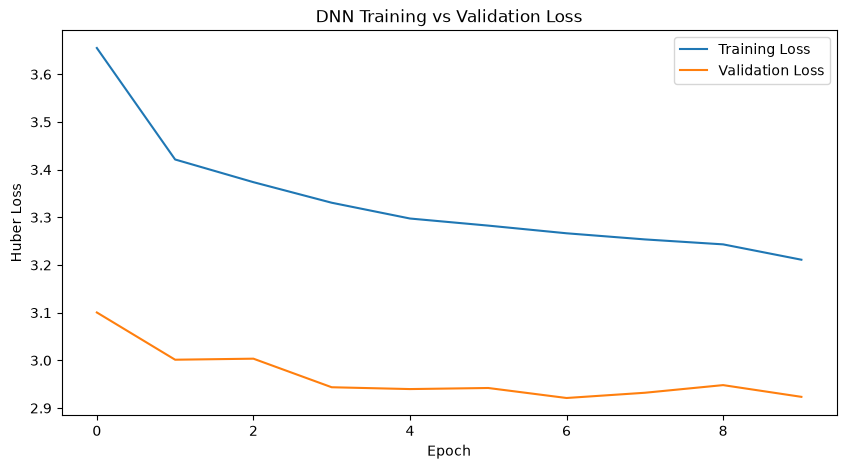

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history_dnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_dnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Huber Loss")

plt.title(
    "DNN Training vs Validation Loss"
)

plt.legend()
plt.show()

### model tuning experiments